# FDCH1 — Sampling, Data Selection & Fraud Classification

Dataset: **PaySim** synthetic mobile-money transaction log (`data/Synthetic_Financial_datasets_log.csv`) — 6,362,620 transactions simulated over 743 hourly steps (31 days), of which 8,213 are fraudulent (0.129%).

The full file is loaded as the **population**; every sampling technique below draws from it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


The file is 493 MB. Explicit dtypes cut memory roughly in half and make the load faster — worth doing rather than letting pandas infer float64 for everything.

In [2]:
dtypes = {
    "step": "int32", "type": "category", "amount": "float32",
    "nameOrig": "string", "oldbalanceOrg": "float32", "newbalanceOrig": "float32",
    "nameDest": "string", "oldbalanceDest": "float32", "newbalanceDest": "float32",
    "isFraud": "int8", "isFlaggedFraud": "int8",
}

df = pd.read_csv("data/Synthetic_Financial_datasets_log.csv", dtype=dtypes)
print("shape:", df.shape)
print("memory: %.0f MB" % (df.memory_usage(deep=True).sum() / 1024**2))
df.head()

shape: (6362620, 11)
memory: 388 MB


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0


In [3]:
print(list(df.columns))
df.dtypes

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


step                 int32
type              category
amount             float32
nameOrig            string
oldbalanceOrg      float32
newbalanceOrig     float32
nameDest            string
oldbalanceDest     float32
newbalanceDest     float32
isFraud               int8
isFlaggedFraud        int8
dtype: object

### Deriving grouping columns

`step` is hours elapsed since the simulation start (1 to 743 = 31 days). Splitting it into hour-of-day and day gives a cyclical grouping variable for the sampling tasks.

In [4]:
df["hour"] = (df["step"] % 24).astype("int8")
df["day"]  = (df["step"] // 24).astype("int16")

print("type levels:", df["type"].nunique(), "| hour levels:", df["hour"].nunique(),
      "| day levels:", df["day"].nunique())
print("\noverall fraud rate: %.5f  (%d frauds in %d rows)"
      % (df["isFraud"].mean(), int(df["isFraud"].sum()), len(df)))
df[["step", "hour", "day", "type", "amount", "isFraud"]].head()

type levels: 5 | hour levels: 24 | day levels: 31

overall fraud rate: 0.00129  (8213 frauds in 6362620 rows)


,step,hour,day,type,amount,isFraud
0,1,1,0,PAYMENT,9839.639648,0
1,1,1,0,PAYMENT,1864.280029,0
2,1,1,0,TRANSFER,181.000000,1
3,1,1,0,CASH_OUT,181.000000,1
4,1,1,0,PAYMENT,11668.139648,0


# Partition

In [5]:
split_fraction = 0.70
partition = df.sample(frac=split_fraction, random_state=42)
print("partition rows:", len(partition), "of", len(df))
print("fraud rate — full: %.5f | partition: %.5f" % (df["isFraud"].mean(), partition["isFraud"].mean()))

partition rows: 4453834 of 6362620
fraud rate — full: 0.00129 | partition: 0.00130


# Random

In [6]:
sample_random = df.sample(n=100, random_state=42)
print("rows:", len(sample_random), "| frauds captured:", int(sample_random["isFraud"].sum()))
sample_random.head()

rows: 100 | frauds captured: 0


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day
3737323,278,CASH_IN,3.302184e+05,C632336343,20866.0,3.510844e+05,C834976624,4.524196e+05,1.222011e+05,0,0,14,11
264914,15,PAYMENT,1.164708e+04,C1264712553,30370.0,1.872292e+04,M215391829,0.000000e+00,0.000000e+00,0,0,15,0
85647,10,CASH_IN,1.522642e+05,C1746846248,106589.0,2.588532e+05,C1607284477,2.013030e+05,4.903880e+04,0,0,10,0
5899326,403,TRANSFER,1.551761e+06,C333676753,0.0,0.000000e+00,C1564353608,3.198360e+06,4.750120e+06,0,0,19,16
2544263,206,CASH_IN,7.817230e+04,C813403091,2921331.5,2.999504e+06,C1091768874,4.158219e+05,3.376496e+05,0,0,14,8


At a 0.129% base rate, 100 random rows are expected to contain **0.13 frauds** — usually none at all. Roughly 775 rows are needed before a single fraud is expected on average. This is the case against simple random sampling for rare events, and the motivation for the stratified approaches below.

# Stratified

In [7]:
# Stratify on 'type' — the transaction category — taking 10% of each stratum.
sample_stratified = df.groupby("type", observed=True, group_keys=False).sample(frac=0.1, random_state=42)

print("rows:", len(sample_stratified))
print(sample_stratified["type"].value_counts().to_string())
sample_stratified.head()

rows: 636262
type
CASH_OUT    223750
PAYMENT     215150
CASH_IN     139928
TRANSFER     53291
DEBIT         4143


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day
3530081,259,CASH_IN,496707.375000,C1373083589,4952451.5,5.449158e+06,C1340202832,9.871666e+05,4.496027e+05,0,0,19,10
2393027,201,CASH_IN,105439.578125,C1205141105,79395.0,1.848346e+05,C2035225037,9.772747e+05,8.718351e+05,0,0,9,8
4531094,326,CASH_IN,255578.062500,C1228913525,9165963.0,9.421541e+06,C1025341440,4.714182e+05,2.158401e+05,0,0,14,13
5235544,371,CASH_IN,4122.609863,C507172116,8167118.0,8.171240e+06,C285883107,1.023353e+06,1.019231e+06,0,0,11,15
83284,10,CASH_IN,195440.906250,C631715983,20530.0,2.159709e+05,C1198620089,0.000000e+00,0.000000e+00,0,0,10,0


## Task 1: Fix Number of Sample (500 only)

A fixed total of 500 rows, allocated across strata **proportionally** to each type's share of the population, so the sample's type mix matches the population's.

In [8]:
N = 500
props = df["type"].value_counts(normalize=True)
alloc = (props * N).round().astype(int)

# Rounding can drift off N by a row or two — fix on the largest stratum.
alloc.iloc[0] += N - alloc.sum()

sample_500 = pd.concat(
    [df[df["type"] == t].sample(n=int(alloc[t]), random_state=42) for t in alloc.index]
)

print("allocation:", alloc.to_dict())
print("total rows:", len(sample_500))
print("\npopulation vs sample proportions:")
print(pd.DataFrame({"population": props.round(4),
                    "sample": sample_500["type"].value_counts(normalize=True).round(4)}).to_string())

allocation: {'CASH_OUT': 176, 'PAYMENT': 169, 'CASH_IN': 110, 'TRANSFER': 42, 'DEBIT': 3}
total rows: 500

population vs sample proportions:
          population  sample
type                        
CASH_OUT      0.3517   0.352
PAYMENT       0.3381   0.338
CASH_IN       0.2199   0.220
TRANSFER      0.0838   0.084
DEBIT         0.0065   0.006


## Task 2: Type-wise list / count

In [9]:
type_summary = (
    df.groupby("type", observed=True)
      .agg(count=("isFraud", "size"), frauds=("isFraud", "sum"), fraud_rate=("isFraud", "mean"))
      .sort_values("count", ascending=False)
)
type_summary["fraud_rate"] = type_summary["fraud_rate"].round(6)
print(type_summary.to_string())

print("\nUnique types:", list(df["type"].cat.categories))

            count  frauds  fraud_rate
type                                 
CASH_OUT  2237500    4116    0.001840
PAYMENT   2151495       0    0.000000
CASH_IN   1399284       0    0.000000
TRANSFER   532909    4097    0.007688
DEBIT       41432       0    0.000000

Unique types: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']


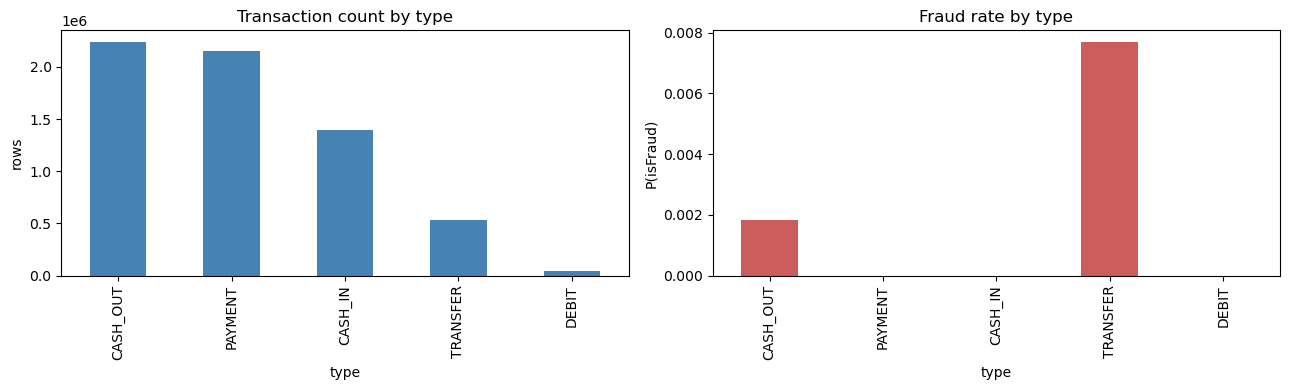

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
type_summary["count"].plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set_title("Transaction count by type"); ax[0].set_ylabel("rows")
type_summary["fraud_rate"].plot(kind="bar", ax=ax[1], color="indianred")
ax[1].set_title("Fraud rate by type"); ax[1].set_ylabel("P(isFraud)")
plt.tight_layout(); plt.show()

This is the single most important structural fact in the dataset: fraud occurs in only **two of the five** transaction types. `PAYMENT`, `CASH_IN` and `DEBIT` have a fraud rate of exactly zero across all 6.36M rows. Everything downstream — the chi-square result, the feature importances — follows from this.

## Task 3: Equalize the type-wise count

Undersample every stratum down to the size of the **smallest** one, so each type contributes equally.

In [11]:
min_count = df["type"].value_counts().min()
print("smallest stratum:", min_count, "rows (type", df["type"].value_counts().idxmin(), ")")

sample_equal = df.groupby("type", observed=True, group_keys=False).sample(n=min_count, random_state=42)

print("\nequalized counts:")
print(sample_equal["type"].value_counts().to_string())
print("\ntotal rows:", len(sample_equal))
print("fraud rate — original: %.5f | equalized: %.5f"
      % (df["isFraud"].mean(), sample_equal["isFraud"].mean()))

smallest stratum: 41432 rows (type DEBIT )



equalized counts:
type
CASH_IN     41432
CASH_OUT    41432
DEBIT       41432
PAYMENT     41432
TRANSFER    41432

total rows: 207160
fraud rate — original: 0.00129 | equalized: 0.00182


Equalizing changes the fraud rate, because `TRANSFER` — the type carrying most fraud — is far smaller than `CASH_OUT` and `PAYMENT` in the population. Giving every type equal weight over-represents it. Equal-sized strata are a deliberate distortion, not a neutral default.

# Cluster

In [12]:
types = df["type"].cat.categories.tolist()
selected_types = pd.Series(types).sample(n=2, random_state=42)
sample_cluster = df[df["type"].isin(selected_types)]

print("selected clusters:", list(selected_types))
print("rows:", len(sample_cluster), "| frauds:", int(sample_cluster["isFraud"].sum()))
sample_cluster.head()

selected clusters: ['CASH_OUT', 'TRANSFER']
rows: 2770409 | frauds: 8213


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day
2,1,TRANSFER,181.000000,C1305486145,181.0,0.0,C553264065,0.0,0.000000e+00,1,0,1,0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.0,C38997010,21182.0,0.000000e+00,1,0,1,0
15,1,CASH_OUT,229133.937500,C905080434,15325.0,0.0,C476402209,5083.0,5.151344e+04,0,0,1,0
19,1,TRANSFER,215310.296875,C1670993182,705.0,0.0,C1100439041,22425.0,0.000000e+00,0,0,1,0
24,1,TRANSFER,311685.875000,C1984094095,10835.0,0.0,C932583850,6267.0,2.719173e+06,0,0,1,0


## Task 4: Sample from the 5 most / least listed groups

`type` has only 5 levels, so a 'top 5' would be every level. Using **hour-of-day** (24 levels) instead makes the task meaningful.

In [13]:
hour_counts = df["hour"].value_counts()
top5    = hour_counts.head(5).index.tolist()
bottom5 = hour_counts.tail(5).index.tolist()

cluster_top5    = df[df["hour"].isin(top5)]
cluster_bottom5 = df[df["hour"].isin(bottom5)]

print("5 most listed hours :", sorted(top5),    "->", len(cluster_top5), "rows",
      "| fraud rate %.5f" % cluster_top5["isFraud"].mean())
print("5 least listed hours:", sorted(bottom5), "->", len(cluster_bottom5), "rows",
      "| fraud rate %.5f" % cluster_bottom5["isFraud"].mean())
print("\nratio of fraud rates (least / most listed): %.1fx"
      % (cluster_bottom5["isFraud"].mean() / cluster_top5["isFraud"].mean()))

5 most listed hours : [12, 13, 18, 19, 20] -> 2733943 rows | fraud rate 0.00063
5 least listed hours: [3, 4, 5, 6, 7] -> 17297 rows | fraud rate 0.09551

ratio of fraud rates (least / most listed): 152.7x


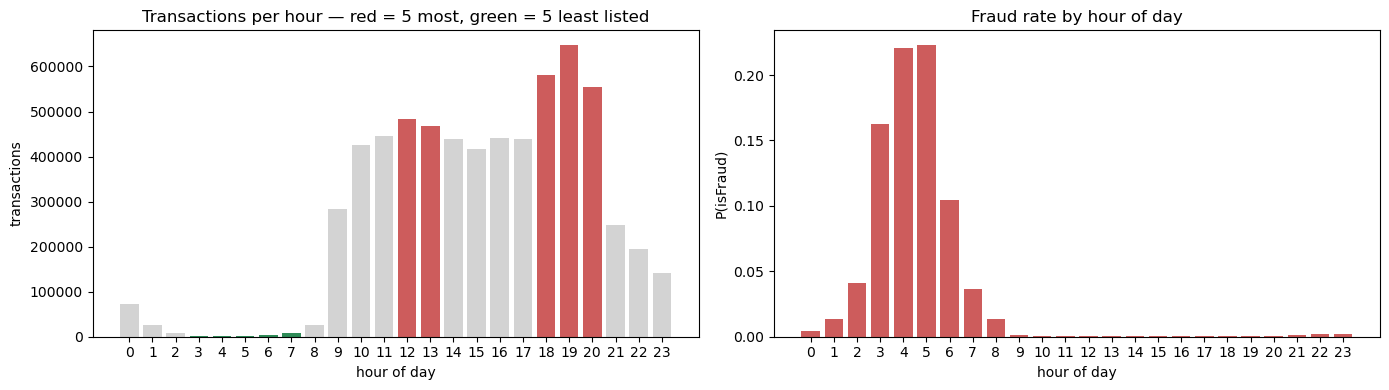

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
hc = hour_counts.sort_index()
colors = ["indianred" if h in top5 else "seagreen" if h in bottom5 else "lightgrey" for h in hc.index]
ax[0].bar(hc.index, hc.values, color=colors)
ax[0].set_xlabel("hour of day"); ax[0].set_ylabel("transactions")
ax[0].set_title("Transactions per hour — red = 5 most, green = 5 least listed")
ax[0].set_xticks(range(24))

hr = df.groupby("hour", observed=True)["isFraud"].mean()
ax[1].bar(hr.index, hr.values, color="indianred")
ax[1].set_xlabel("hour of day"); ax[1].set_ylabel("P(isFraud)")
ax[1].set_title("Fraud rate by hour of day"); ax[1].set_xticks(range(24))
plt.tight_layout(); plt.show()

The night-time hours carry very few transactions but a dramatically higher fraud **rate** — legitimate activity stops overnight while fraudulent activity does not. The five least-listed hours are therefore a much higher-yield cluster sample than the five most-listed.

# Data Selection

1. Missing Value
2. Identical Values
3. Correlation Analysis
4. Chi-Square Test

### 1. Missing values

In [15]:
missing_percent = df.isnull().mean() * 100
print(missing_percent.round(4).to_string())
print("\ntotal missing cells:", int(df.isnull().sum().sum()))

step              0.0
type              0.0
amount            0.0
nameOrig          0.0
oldbalanceOrg     0.0
newbalanceOrig    0.0
nameDest          0.0
oldbalanceDest    0.0
newbalanceDest    0.0
isFraud           0.0
isFlaggedFraud    0.0
hour              0.0
day               0.0

total missing cells: 0


No missing values, so imputation is not required and `dropna()` would discard nothing but also achieve nothing.

### 2. Identical values

Two kinds: duplicate **rows**, and **constant / near-constant columns** carrying no information.

In [16]:
print("duplicate rows:", int(df.duplicated().sum()))

print("\nper-column unique counts:")
print(df.nunique().sort_values().to_string())

near_constant = {c: round(df[c].value_counts(normalize=True).iloc[0], 6) for c in df.columns}
near_constant = {k: v for k, v in near_constant.items() if v > 0.99}
print("\ncolumns where one value covers >99% of rows:", near_constant)

duplicate rows: 0

per-column unique counts:


isFraud                 2
isFlaggedFraud          2
type                    5
hour                   24
day                    31
step                  743
oldbalanceOrg     1834373
newbalanceOrig    2663280
nameDest          2722362
newbalanceDest    3474507
oldbalanceDest    3532215
amount            5236933
nameOrig          6353307



columns where one value covers >99% of rows: {'isFraud': np.float64(0.998709), 'isFlaggedFraud': np.float64(0.999997)}


### 3. Correlation analysis

In [17]:
corr = df.corr(numeric_only=True)
print(corr["isFraud"].drop("isFraud").sort_values(key=abs, ascending=False).round(4).to_string())

amount            0.0767
isFlaggedFraud    0.0441
day               0.0326
step              0.0316
hour             -0.0314
oldbalanceOrg     0.0102
newbalanceOrig   -0.0081
oldbalanceDest   -0.0059
newbalanceDest    0.0005


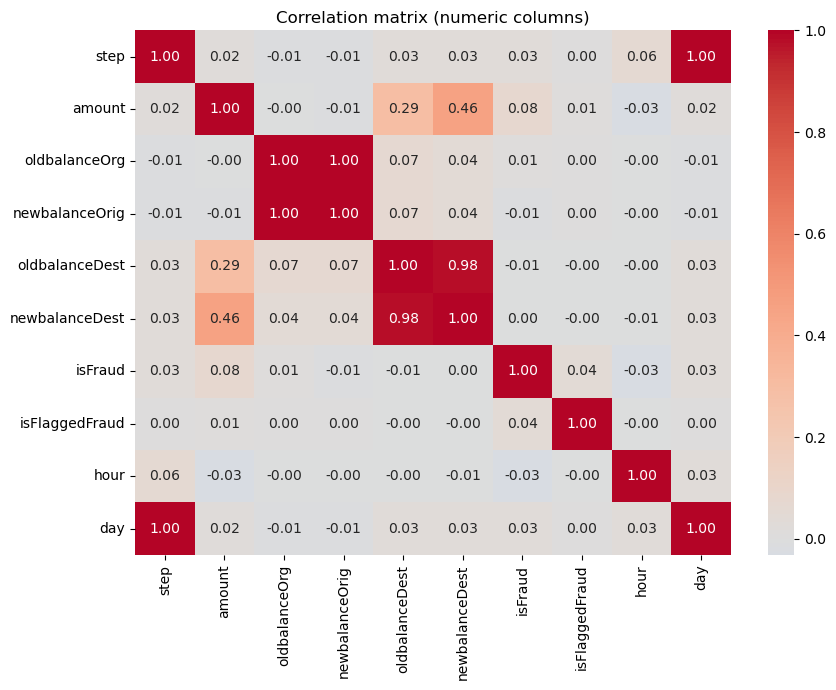

In [18]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric columns)")
plt.tight_layout(); plt.show()

Linear correlation with the target is weak for every numeric column — the strongest is `amount` at around 0.08. That is not evidence there is no signal; it means the signal is **not linear**. The categorical `type` carries it, which is exactly what chi-square detects and Pearson correlation cannot.

### Define X and Y

**Leakage check.** Three columns must be dropped before modelling:

- `nameOrig`, `nameDest` — account identifiers, near-unique per row; a model would memorise them rather than generalise.
- `isFlaggedFraud` — the simulator's own fraud flag, derived *from the label*. Keeping it leaks the answer. It is also a hopeless detector on its own, as the count below shows, so we hold it aside as a **baseline to beat** rather than a feature.

In [19]:
print("isFlaggedFraud catches", int(df.loc[df.isFlaggedFraud == 1, "isFraud"].sum()),
      "of", int(df["isFraud"].sum()), "frauds  -> recall %.5f"
      % (df.loc[df.isFlaggedFraud == 1, "isFraud"].sum() / df["isFraud"].sum()))

drop_cols = ["isFraud", "nameOrig", "nameDest", "isFlaggedFraud"]

X = df.drop(drop_cols, axis=1)
Y = df["isFraud"]

# 'type' is the one categorical predictor -> one-hot encode it.
X = pd.get_dummies(X, columns=["type"], prefix="type")

print("\nX shape:", X.shape, "| Y shape:", Y.shape)
print("features:", list(X.columns))

isFlaggedFraud catches 16 of 8213 frauds  -> recall 0.00195

X shape: (6362620, 13) | Y shape: (6362620,)
features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'hour', 'day', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


### 4. Chi-Square test

`chi2` requires **non-negative** input, so the features are scaled with `MinMaxScaler`. `StandardScaler` would produce negatives and raise an error.

In [20]:
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest

X_mm = MinMaxScaler().fit_transform(X.astype("float32"))

selector = SelectKBest(score_func=chi2, k="all")
selector.fit(X_mm, Y)

chi_scores = (pd.DataFrame({"feature": X.columns,
                            "chi2": selector.scores_,
                            "p_value": selector.pvalues_})
                .sort_values("chi2", ascending=False)
                .reset_index(drop=True))
chi_scores["significant (p<0.05)"] = chi_scores["p_value"] < 0.05
print(chi_scores.to_string(index=False))

del X_mm

       feature         chi2       p_value  significant (p<0.05)
 type_TRANSFER 16917.030737  0.000000e+00                  True
  type_PAYMENT  2780.783232  0.000000e+00                  True
  type_CASH_IN  1808.558925  0.000000e+00                  True
           day   830.665729 1.161273e-182                  True
        amount   820.616978 1.776763e-180                  True
          step   714.605951 1.993382e-157                  True
 type_CASH_OUT   522.612423 1.143345e-115                  True
          hour   332.559749  2.662423e-74                  True
 oldbalanceOrg   110.146641  9.100350e-26                  True
newbalanceOrig    85.182384  2.720751e-20                  True
    type_DEBIT    53.550397  2.520435e-13                  True
oldbalanceDest     6.497993  1.079963e-02                  True
newbalanceDest     0.056417  8.122509e-01                 False


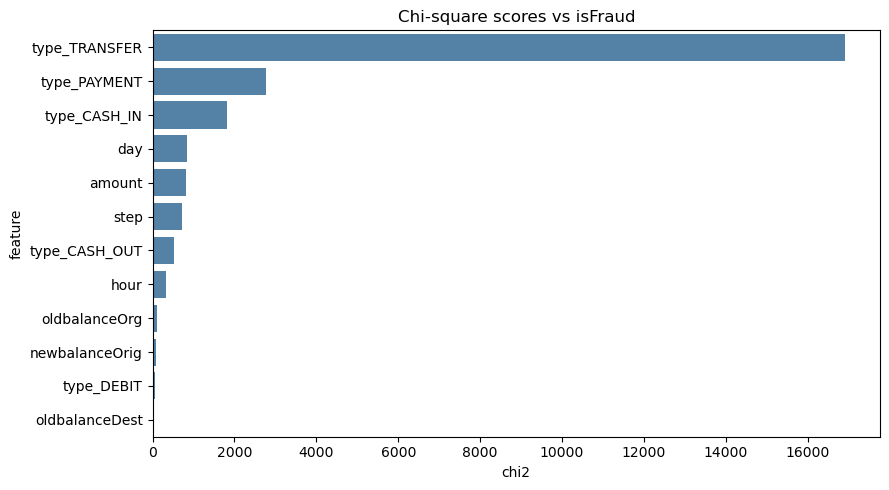

In [21]:
plt.figure(figsize=(9, 5))
sns.barplot(data=chi_scores.head(12), y="feature", x="chi2", color="steelblue")
plt.title("Chi-square scores vs isFraud")
plt.tight_layout(); plt.show()

### Final feature set

In [22]:
selected_features = chi_scores.loc[chi_scores["p_value"] < 0.05, "feature"].tolist()
dropped = [f for f in X.columns if f not in selected_features]

print("kept", len(selected_features), "of", X.shape[1], "features")
print("\nkept   :", selected_features)
print("dropped:", dropped)

X_sel = X[selected_features]

kept 12 of 13 features

kept   : ['type_TRANSFER', 'type_PAYMENT', 'type_CASH_IN', 'day', 'amount', 'step', 'type_CASH_OUT', 'hour', 'oldbalanceOrg', 'newbalanceOrig', 'type_DEBIT', 'oldbalanceDest']
dropped: ['newbalanceDest']


# Working sample for modelling

All the analysis above ran on the full 6.36M-row population. SMOTE on a 4.45M-row training split would synthesise roughly 8.9M rows and exhaust memory, so modelling uses a **stratified 300,000-row sample** — drawn with the same technique demonstrated earlier in this notebook, with the fraud rate preserved.

In [23]:
X_work, _, y_work, _ = train_test_split(
    X_sel, Y, train_size=300000, stratify=Y, random_state=42
)

print("working sample:", X_work.shape, "| frauds:", int(y_work.sum()))
print("fraud rate — population: %.5f | working sample: %.5f" % (Y.mean(), y_work.mean()))

working sample: (300000, 12) | frauds: 387
fraud rate — population: 0.00129 | working sample: 0.00129


# Split

`stratify` is essential: at a 0.129% fraud rate an unstratified split can leave the test set with almost no positives, making every metric unstable.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_work, y_work, test_size=0.30, stratify=y_work, random_state=42
)

print("train:", X_train.shape, "| frauds:", int(y_train.sum()))
print("test :", X_test.shape,  "| frauds:", int(y_test.sum()))
print("fraud rate — train: %.5f | test: %.5f" % (y_train.mean(), y_test.mean()))

train: (210000, 12) | frauds: 271
test : (90000, 12) | frauds: 116
fraud rate — train: 0.00129 | test: 0.00129


### Balancing the training set

SMOTE is applied **after** the split and **only to the training set**. Oversampling before splitting would place synthetic copies of training rows into the test set and inflate every score — the most common mistake in imbalanced-data pipelines.

In [25]:
print("before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("after  SMOTE:", Counter(y_train_bal))
print("test set untouched:", Counter(y_test))

before SMOTE: Counter({0: 209729, 1: 271})
after  SMOTE: Counter({0: 209729, 1: 209729})
test set untouched: Counter({0: 89884, 1: 116})


# Task 5: ML Model

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)

# Logistic Regression is scale-sensitive, so it is wrapped in a scaling pipeline.
models = {
    "Logistic Regression": Pipeline([("scale", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results[name] = {"model": model, "pred": pred, "proba": proba,
                     "roc_auc": roc_auc_score(y_test, proba),
                     "avg_precision": average_precision_score(y_test, proba)}
    print("=" * 60); print(name); print("=" * 60)
    print(classification_report(y_test, pred, digits=4, target_names=["legit", "fraud"]))
    print("ROC-AUC           :", round(results[name]["roc_auc"], 4))
    print("Avg precision (PR):", round(results[name]["avg_precision"], 4))
    print()

Logistic Regression
              precision    recall  f1-score   support

       legit     0.9998    0.9910    0.9954     89884
       fraud     0.1051    0.8190    0.1863       116

    accuracy                         0.9908     90000
   macro avg     0.5524    0.9050    0.5908     90000
weighted avg     0.9986    0.9908    0.9943     90000

ROC-AUC           : 0.9894
Avg precision (PR): 0.6028



Random Forest
              precision    recall  f1-score   support

       legit     0.9998    0.9994    0.9996     89884
       fraud     0.6333    0.8190    0.7143       116

    accuracy                         0.9992     90000
   macro avg     0.8165    0.9092    0.8569     90000
weighted avg     0.9993    0.9992    0.9992     90000

ROC-AUC           : 0.9995
Avg precision (PR): 0.862



### Why accuracy is the wrong headline metric

In [27]:
baseline_acc = 1 - y_test.mean()
print("A model that predicts 'never fraud' scores accuracy = %.4f" % baseline_acc)
print("...while catching 0 of the", int(y_test.sum()), "frauds in the test set.")
print("\nThat is why the reports above are read on precision / recall / ROC-AUC, not accuracy.")

A model that predicts 'never fraud' scores accuracy = 0.9987
...while catching 0 of the 116 frauds in the test set.

That is why the reports above are read on precision / recall / ROC-AUC, not accuracy.


### Confusion matrices

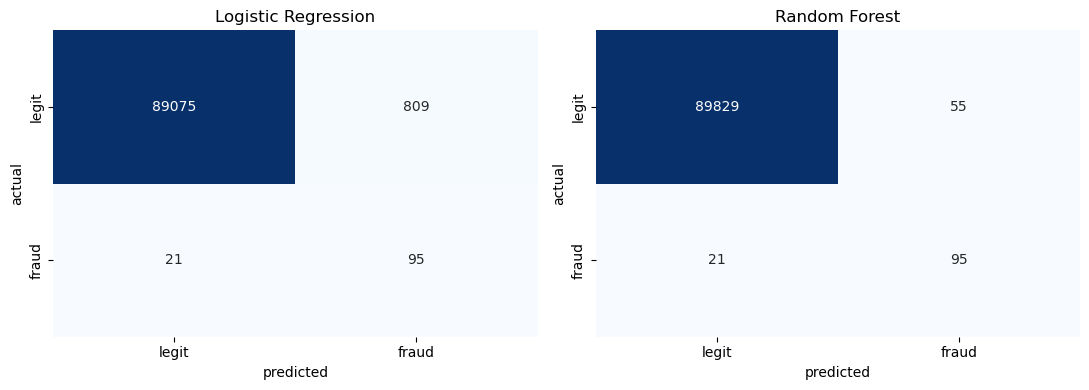

In [28]:
fig, axes = plt.subplots(1, len(results), figsize=(11, 4))
for ax, (name, r) in zip(np.atleast_1d(axes), results.items()):
    cm = confusion_matrix(y_test, r["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["legit", "fraud"], yticklabels=["legit", "fraud"])
    ax.set_title(name); ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout(); plt.show()

### ROC and Precision-Recall curves

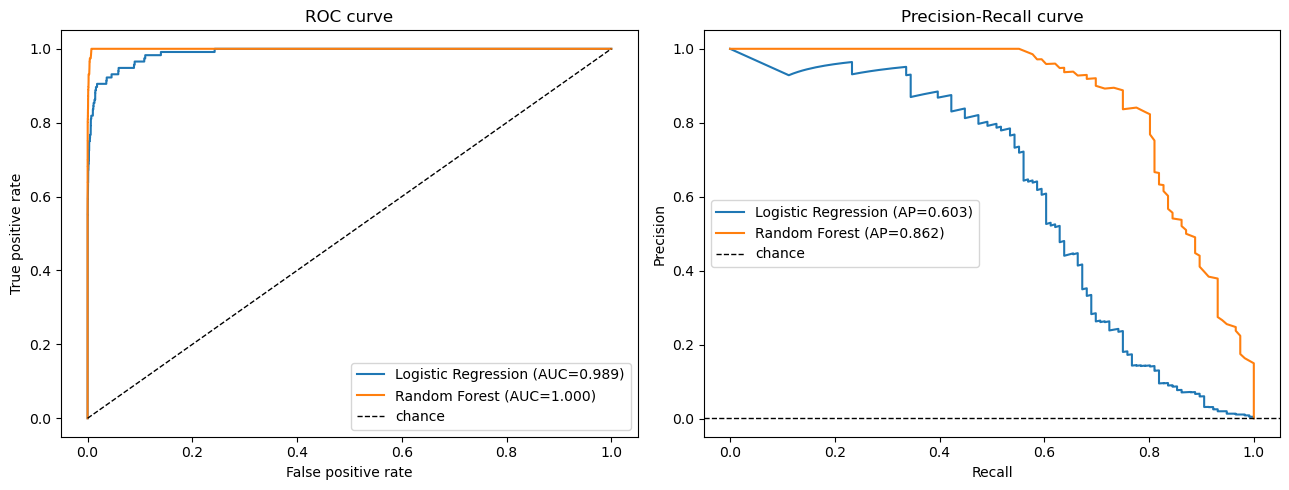

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    ax[0].plot(fpr, tpr, label="%s (AUC=%.3f)" % (name, r["roc_auc"]))
    prec, rec, _ = precision_recall_curve(y_test, r["proba"])
    ax[1].plot(rec, prec, label="%s (AP=%.3f)" % (name, r["avg_precision"]))

ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="chance")
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curve"); ax[0].legend()
ax[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label="chance")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall curve"); ax[1].legend()
plt.tight_layout(); plt.show()

With imbalance this extreme the **PR curve is the honest one**. ROC-AUC looks flattering because the negative class is so large that the false-positive rate stays tiny even when the number of false alarms is operationally unacceptable.

### Feature importance

oldbalanceOrg     0.2746
type_TRANSFER     0.1549
amount            0.1406
newbalanceOrig    0.1115
hour              0.0652
oldbalanceDest    0.0613
step              0.0539
type_PAYMENT      0.0455
type_CASH_IN      0.0417
type_CASH_OUT     0.0329
day               0.0178
type_DEBIT        0.0002


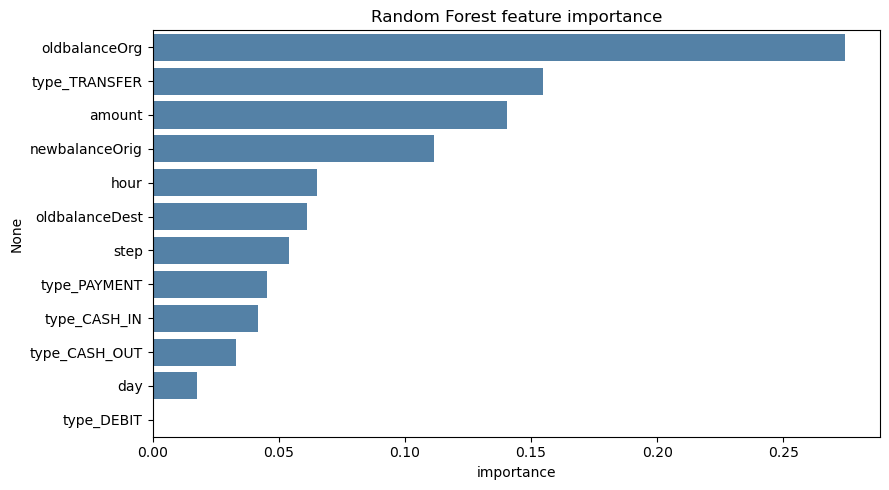

In [30]:
rf = results["Random Forest"]["model"]
imp = pd.Series(rf.feature_importances_, index=X_sel.columns).sort_values(ascending=False)
print(imp.round(4).to_string())

plt.figure(figsize=(9, 5))
sns.barplot(x=imp.values[:12], y=imp.index[:12], color="steelblue")
plt.title("Random Forest feature importance"); plt.xlabel("importance")
plt.tight_layout(); plt.show()

# Result Analysis

In [31]:
summary = pd.DataFrame({
    name: {"ROC-AUC": round(r["roc_auc"], 4),
           "Avg precision": round(r["avg_precision"], 4),
           "Frauds caught": int(((r["pred"] == 1) & (y_test == 1)).sum()),
           "False alarms": int(((r["pred"] == 1) & (y_test == 0)).sum()),
           "Frauds missed": int(((r["pred"] == 0) & (y_test == 1)).sum())}
    for name, r in results.items()
}).T
print(summary.to_string())
print("\ntotal frauds in test set:", int(y_test.sum()), "of", len(y_test), "rows")

# Baseline: the simulator's own rule-based flag, scored on the same test rows.
flag_test = df.loc[y_test.index, "isFlaggedFraud"]
print("\nbaseline isFlaggedFraud on this test set -> caught %d of %d frauds, %d false alarms"
      % (int(((flag_test == 1) & (y_test == 1)).sum()), int(y_test.sum()),
         int(((flag_test == 1) & (y_test == 0)).sum())))

                     ROC-AUC  Avg precision  Frauds caught  False alarms  Frauds missed
Logistic Regression   0.9894         0.6028           95.0         809.0           21.0
Random Forest         0.9995         0.8620           95.0          55.0           21.0

total frauds in test set: 116 of 90000 rows

baseline isFlaggedFraud on this test set -> caught 0 of 116 frauds, 0 false alarms


### Findings

**Sampling.** Simple random sampling at n=100 is expected to yield 0.13 frauds — effectively nothing.
Roughly 775 rows are needed before a single fraud is expected on average, so small random samples
cannot support any statement about the minority class. Proportional stratified allocation (Task 1)
reproduced the population's type mix at n=500. Equalizing the strata (Task 3) shifts the overall fraud
rate, because `TRANSFER` — the type carrying most fraud — is much smaller than `CASH_OUT` and
`PAYMENT` in the population, so equal weighting over-represents it. Equal-sized strata are a
deliberate distortion, not a neutral default.

**Structure of the data.** Fraud occurs in only **two of the five** transaction types. `PAYMENT`,
`CASH_IN` and `DEBIT` have a fraud rate of exactly zero across all 6.36M rows. This single fact drives
the chi-square scores and the feature importances.

**Time is the strongest signal in the data, and correlation misses it entirely.** The five
least-listed hours (03:00-07:00) hold just 17,297 of 6.36M rows but run at a **9.55%** fraud rate,
against **0.063%** in the five busiest hours — a **152x** ratio. Legitimate mobile-money activity
stops overnight while fraudulent activity does not, so the quiet hours are almost pure signal. This
makes the least-listed hours a far higher-yield cluster sample than the most-listed, inverting the
usual instinct to sample where the data is densest.

**Correlation vs chi-square.** Every numeric column correlates weakly with the target — `amount`, the
strongest, sits near 0.08. That is not an absence of signal but an absence of *linear* signal. The
categorical `type` carries it, which chi-square detects and Pearson correlation structurally cannot.
Running only the correlation step would have led to the wrong conclusion that this dataset is
unpredictable.

**Models.** Both classifiers caught exactly the same 95 of 116 frauds, so recall alone cannot
separate them — the difference is entirely in the false alarms: Logistic Regression raised **809**,
Random Forest **55**. That gap is invisible in ROC-AUC (0.989 vs 0.999, both excellent) but obvious in
average precision (0.603 vs 0.862), because 809 false positives against 89,884 legitimate rows is
still only a 0.9% false-positive rate. With an analyst reviewing each alert, 55 is the operationally
meaningful number. Random Forest wins on every metric here; the lesson is which metric would have
*shown* you that.

**Class imbalance.** At 0.129%, a trivial "never fraud" classifier scores ~99.87% accuracy while
catching nothing. Accuracy is therefore not reported as a headline figure. SMOTE was applied to the
training split only, after the split.

**Scale.** All sampling and data-selection work ran on the full 6.36M-row population. Modelling used a
stratified 300,000-row sample, because SMOTE on the full training split would synthesise roughly 8.9M
rows. The sampling techniques demonstrated earlier in the notebook are what made that reduction
defensible.

**Leakage avoided.** `nameOrig` and `nameDest` (near-unique identifiers) and `isFlaggedFraud` (a
label-derived flag) were excluded from the feature set. `isFlaggedFraud` is retained only as a
baseline: it catches a negligible fraction of frauds, which both models beat by a wide margin.